# <CENTER> **PROJECT: Imitation Learning (Behavioral Cloning и DAgger)**

---

В этом задании вы познакомитесь с методами **имитационного обучения (Imitation Learning)** — подходом к обучению агентов, при котором они учатся напрямую копировать поведение эксперта, не получая при этом явного сигнала награды от среды. Такие методы особенно полезны, когда:
- награда разрежена или недоступна,
- экспертное поведение легко продемонстрировать, но трудно формализовать,
- требуется быстро получить рабочую политику без длительного взаимодействия со средой.

Вы реализуете два ключевых алгоритма:
1. **Behavioral Cloning (BC)** — простейший метод, сводящийся к задаче регрессии: по состоянию предсказать действие эксперта.
2. **DAgger (Dataset Aggregation)** — итеративный метод, который решает проблему *covariate shift*, активно собирая опыт в тех состояниях, куда попадает обучаемая политика.

---

## Установка среды

In [4]:
import os
os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"

# import os
# if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
#     !bash xvfb start
#     os.environ['DISPLAY'] = ':1'

!pip install dm_control>=1.0.34  #torch==2.2.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install shimmy[dm-control]
!pip install gymnasium
!pip install torchinfo

# import warnings; warnings.filterwarnings(action="ignore", message=r"datetime.datetime.utcnow")
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="pkg_resources")
warnings.filterwarnings("ignore", message="datetime.datetime.utcnow")

## Проверка установки и рендеринг среды MuJoCo  
Убедитесь, что среда корректно установлена и можно получить изображения из неё.


In [5]:
import gymnasium as gym
import numpy as np
from dm_control import suite
from dm_control.suite.wrappers import pixels
from shimmy import DmControlCompatibilityV0

warnings.filterwarnings(action="ignore", message=r"datetime.datetime.utcnow")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

### Обёртка для рендеринга в средах DeepMind Control Suite  
Поскольку оригинальная среда `dm_control` не предоставляет метод `.render()` в формате, совместимом с Gymnasium, мы создаём собственную обёртку `DmControlWithRender`.  
Эта обёртка добавляет метод `render()`, который использует встроенный рендерер MuJoCo для получения изображений заданного разрешения и с нужной камеры.

In [6]:
class DmControlWithRender(gym.Wrapper):
    def __init__(self, env, height=84, width=84, camera_id=0):
        super().__init__(env)
        self._height = height
        self._width = width
        self._camera_id = camera_id

    def render(self):
        # Access the underlying dm_control env
        dm_env = self.unwrapped._env
        return dm_env.physics.render(
            height=self._height,
            width=self._width,
            camera_id=self._camera_id
        )

### Фабрика среды (`make_env`)  
Функция `make_env` создаёт настраиваемую среду с поддержкой различных полезных обёрток из Gymnasium:

- **`domain`, `task`** — определяют конкретную задачу (например, `"cheetah"` / `"run"`).
- **`frame_stack`** — количество последовательных наблюдений, объединяемых в одно состояние (полезно при обучении на изображениях или для учёта динамики).
- **`flatten_frames`** — если включено, наблюдения (даже стекированные) преобразуются в одномерный вектор.
- **`render_enabled`** — добавляет возможность рендеринга через обёртку `DmControlWithRender`.
- **`record_stats`** — включает сбор статистики по эпизодам (награда, длина и т.д.).
- **`transform_reward`** — применяет нормализацию и ограничение награды (использовалось при обучении эксперта).
- **`hw`** — высота и ширина изображения при рендеринге. Рекомендуется использовать небольшие значения (например, 64) для ускорения работы; максимальное разрешение — 480×480.

Эта функция возвращает *thunk* — callable без аргументов, который создаёт и возвращает готовую среду. Такой подход удобен при векторизации сред (например, через `gym.vector.SyncVectorEnv`).

In [7]:
def make_env(
        domain,
        task,
        frame_stack=1,
        flatten_frames=True,
        render_enabled=True,
        record_stats=False,
        transform_reward=False,
        gamma=0.99,
        hw=64,
    ):
    def thunk():
        dm_env = suite.load(
            domain_name=domain,
            task_name=task,
            task_kwargs=None,
            environment_kwargs=None,
            visualize_reward=False,
        )
        env = DmControlCompatibilityV0(dm_env)
        env = gym.wrappers.FlattenObservation(env) # dict obs -> vector

        # Only add render method if needed (doesn't affect obs)
        if render_enabled:
            env = DmControlWithRender(env, height=hw, width=hw)

        # Observation is always numeric state → consistent!
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            env = gym.wrappers.DtypeObservation(env, np.float32)
        if record_stats:
          env = gym.wrappers.RecordEpisodeStatistics(env)
        env = gym.wrappers.ClipAction(env)
        if transform_reward:
          env = gym.wrappers.NormalizeReward(env, gamma=gamma)
          env = gym.wrappers.TransformReward(env, lambda r: np.clip(r, -10, 10))

        # if frame_stack > 1:
        env = gym.wrappers.FrameStackObservation(env, stack_size=frame_stack)
        if flatten_frames:
            env = gym.wrappers.FlattenObservation(env)
        return env
    return thunk

**Инициализация среды**

Чтобы создать **одну** среду, достаточно вызвать фабричную функцию `make_env` и сразу же выполнить возвращаемый *thunk*:

```python
env = make_env(domain="cheetah", task="run", ...)()
```

Этот вызов создаёт экземпляр среды с заданными параметрами и готов к использованию: можно вызывать `env.reset()`, `env.step(action)` и т.д.

**Немного о векторизованных средах**  (`SyncVectorEnv`)

Однако при обучении агентов (особенно с помощью методов типа PPO или A2C) часто требуется **параллельно взаимодействовать с несколькими копиями среды**. Это позволяет:
- ускорить сбор данных за счёт параллелизма,
- уменьшить корреляцию между последовательными наблюдениями,
- стабилизировать обучение за счёт более разнообразного опыта.

Для этого в Gymnasium предусмотрен класс `SyncVectorEnv`, который объединяет несколько независимых сред в один векторизованный объект. Пример:

```python
from gymnasium.vector import SyncVectorEnv

num_envs = 4
envs = SyncVectorEnv([
    make_env(domain="cheetah", task="run", ...)
    for _ in range(num_envs)
])
```

Теперь `envs` ведёт себя как единая среда, но на самом деле управляет `num_envs` независимыми инстансами:
- `envs.reset()` возвращает массив наблюдений формы `(num_envs, obs_dim)`,
- `envs.step(actions)` принимает массив действий формы `(num_envs, act_dim)` и возвращает соответствующие награды, следующие состояния и флаги завершения.

Важно: `SyncVectorEnv` работает **синхронно** — все среды выполняются последовательно в основном потоке. Для настоящего параллелизма (в отдельных процессах) можно использовать `AsyncVectorEnv`, но для большинства учебных и прототипных задач `SyncVectorEnv` более чем достаточно и проще в отладке.

Этот подход используется, например, при загрузке эксперта: даже если нужна всего одна среда, её всё равно удобно оборачивать в `SyncVectorEnv`, чтобы архитектура агента (`Agent`) могла работать с батчами наблюдений (`envs.single_observation_space` и `envs.single_action_space` дают доступ к пространству одной среды).

In [8]:
# Cоздайте среду для задачи cheetah run
env = make_env(
    domain = 'cheetah',
    task = 'run',
    frame_stack = 1,
    flatten_frames = True,
    render_enabled = True,
    record_stats = True
)()

In [9]:
env.observation_space

Box(-inf, inf, (17,), float32)

In [10]:
env.action_space

Box(-inf, inf, (6,), float64)

In [11]:
env.reset()

(array([-0.09105861,  0.02735307, -0.06491791, -0.0197195 , -0.09358171,
         0.00777844, -0.00583643,  0.00904552,  0.0036316 , -0.00359346,
         0.00315967,  0.01130433,  0.01196881,  0.00673736, -0.00013243,
        -0.01890002, -0.01889091], dtype=float32),
 {'timestep.discount': None, 'timestep.step_type': <StepType.FIRST: 0>})

array([[[ 67, 100, 134],
        [ 67, 100, 134],
        [ 69, 102, 136],
        ...,
        [ 68, 101, 135],
        [ 70, 103, 136],
        [ 67, 101, 135]],

       [[ 66, 100, 133],
        [ 66, 100, 133],
        [ 66, 100, 134],
        ...,
        [ 68, 101, 134],
        [ 67, 101, 134],
        [ 66, 100, 133]],

       [[ 66,  99, 133],
        [ 66,  99, 133],
        [ 66, 100, 133],
        ...,
        [ 72, 104, 137],
        [ 67, 100, 133],
        [ 67, 100, 133]],

       ...,

       [[ 36,  54,  72],
        [ 36,  54,  72],
        [ 38,  56,  74],
        ...,
        [ 39,  56,  74],
        [ 36,  54,  72],
        [ 38,  56,  73]],

       [[ 35,  53,  70],
        [ 35,  53,  70],
        [ 36,  53,  71],
        ...,
        [ 36,  53,  71],
        [ 35,  53,  71],
        [ 36,  54,  71]],

       [[ 36,  54,  71],
        [ 35,  52,  70],
        [ 35,  52,  70],
        ...,
        [ 39,  57,  74],
        [ 36,  53,  71],
        [ 35,  52,  70]]], dtype=uint8)
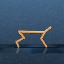

In [12]:
env.render()

Среда **MuJoCo** (в рамках DeepMind Control Suite) предоставляет множество различных задач, каждая из которых может рендериться с разных камер и имеет свои особенности динамики. Например:

- `walker / walk` — двуногий ходячий робот, обучающийся устойчиво передвигаться;
- `hopper / hop` — одноногий прыгающий агент;
- `cartpole / balance` — классическая задача балансировки на тележке;
- `reacher / easy` — манипулятор, который должен дотянуться до цели;
- `finger / spin` — задача вращения объекта с помощью двухпалого захвата;
- `cheetah / run` — четвероногий робот-гепард, обучающийся бегу вперёд.

Все эти среды поддерживают рендеринг с разных точек зрения (камер), что позволяет визуализировать поведение агента под разными углами. Однако для данного домашнего задания мы будем использовать только одну задачу — **`cheetah / run`**, так как именно для неё предоставлен экспертный агент и датасет.

## Загрузка экспертного агента

Загружаем предобученного эксперта — агента, обученного с помощью PPO.  

Для работы с этим заданием рекомендуется:

1. [Скачать папку](https://drive.google.com/drive/folders/1KAHb73CbOvmtGLKFVOHPUjQ44tFy74Mw?usp=sharing) с весами и конфигурацией к себе на **Google Диск**. В этой папке вы можете найти чекпоинты для 3х сред: `cheetah-run`, `hopper-hop` и `walker-run`, однако для этого задания нам понадобятся только `cheetah-run`.
2. Подключить Google Диск к среде Colab.


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


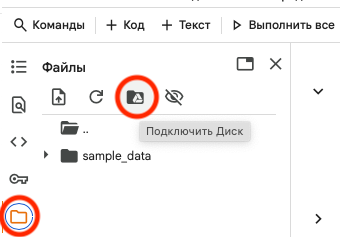

3. Убедиться, что путь `checkpoint_path` указывает на правильное расположение файлов `config.pt` и `checkpoint.pt`.

In [14]:
ls "/content/drive/MyDrive/cheetah-run-expert"

 118500/   checkpoint.pt  'Colab Notebooks'/   config/   config.pt


In [15]:
checkpoint_path = "/content/drive/MyDrive/cheetah-run-expert"
config_name = "config.pt"
checkpoint_name = "checkpoint.pt"

### Вспомогательные функции для нормализации наблюдений

Для стабильного обучения и оценки политик в RL часто используется **нормализация наблюдений** — приведение входных данных к нулевому среднему и единичной дисперсии.  
Класс `RunningMeanStd` реализует **онлайн-оценку среднего и дисперсии** по приходящим батчам данных, используя **параллельный алгоритм обновления моментов**.

Этот подход позволяет:
- эффективно обновлять статистики без хранения всей истории,
- корректно объединять статистики из разных источников (например, при распределённом сборе данных),
- избежать численной нестабильности, связанной с наивным подсчётом дисперсии.

In [16]:
import torch
import torch.nn as nn
from torch.distributions.normal import Normal

def update_mean_var_count_from_moments(mean, var, count, batch_mean, batch_var, batch_count):
    """Updates the mean, var and count using the previous mean, var, count and batch values."""
    delta = batch_mean - mean
    tot_count = count + batch_count

    new_mean = mean + delta * batch_count / tot_count
    m_a = var * count
    m_b = batch_var * batch_count
    M2 = m_a + m_b + torch.square(delta) * count * batch_count / tot_count
    new_var = M2 / tot_count
    new_count = tot_count

    return new_mean, new_var, new_count


class RunningMeanStd(nn.Module):
    """Tracks the mean, variance and count of values."""

    # https://en.wikipedia.org/wiki/Algorithms_for_calculating_variance#Parallel_algorithm
    def __init__(self, shape=(), epsilon=1e-4, dtype=torch.float32):
        super().__init__()
        """Tracks the mean, variance and count of values."""
        self.register_buffer("mean", torch.zeros(shape, dtype=dtype))
        self.register_buffer("var", torch.zeros(shape, dtype=dtype))
        self.register_buffer("count", torch.as_tensor(epsilon, dtype=dtype))

    def update(self, x):
        """Updates the mean, var and count from a batch of samples."""
        batch_mean = torch.mean(x, dim=0)
        batch_var = torch.var(x, dim=0)
        batch_count = x.shape[0]
        self.__update_from_moments(batch_mean, batch_var, batch_count)

    def __update_from_moments(self, batch_mean, batch_var, batch_count):
        """Updates from batch mean, variance and count moments."""
        self.mean, self.var, self.count = update_mean_var_count_from_moments(
            self.mean, self.var, self.count, batch_mean, batch_var, batch_count
        )

### Архитектура агента

Агент состоит из двух нейросетей:
- **Актёр (`actor_mean`)** — предсказывает среднее значение действия в виде гауссовой политики.
- **Критик (`critic`)** — оценивает ценность (value) текущего состояния.

Особенности:
- Используется **ортогональная инициализация весов** (`layer_init`).
- Логарифм стандартного отклонения (`actor_logstd`) обучается как глобальный параметр (не зависит от состояния).
- Наблюдения **нормализуются онлайн** с помощью `RunningMeanStd`.
- Для совместимости с Gymnasium и векторизованными средами агент принимает среду типа `SyncVectorEnv`, но работает и с одной средой. При инициализации в него нужно подать такую среду.

Метод `act_numpy` позволяет удобно вызывать агента из NumPy-кода (например, при сборе траекторий).

In [17]:
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer


class Agent(nn.Module):
    def __init__(self, envs, hidden_dim=64, obs_norm_eps=1e-8):
        super().__init__()
        input_dim = np.array(envs.single_observation_space.shape).prod()

        self.obs_rms = RunningMeanStd(input_dim)
        self.obs_norm_eps = obs_norm_eps

        self.critic = nn.Sequential(
            layer_init(nn.Linear(input_dim, hidden_dim)),
            nn.Tanh(),
            layer_init(nn.Linear(hidden_dim, hidden_dim)),
            nn.Tanh(),
            layer_init(nn.Linear(hidden_dim, 1), std=1.0),
        )
        self.actor_mean = nn.Sequential(
            layer_init(nn.Linear(input_dim, hidden_dim)),
            nn.Tanh(),
            layer_init(nn.Linear(hidden_dim, hidden_dim)),
            nn.Tanh(),
            layer_init(nn.Linear(hidden_dim, np.prod(envs.single_action_space.shape)), std=0.01),
        )
        self.actor_logstd = nn.Parameter(torch.zeros(1, np.prod(envs.single_action_space.shape)))

    def update_obs_rms(self, x):
        self.obs_rms.update(x)

    def normalize_obs(self, x):
        normalized_obs = (x - self.obs_rms.mean) / torch.sqrt(self.obs_rms.var + self.obs_norm_eps)
        # const taken from the cleanrl
        normalized_obs = torch.clamp(normalized_obs, -10, 10)
        return normalized_obs

    def get_value(self, x):
        return self.critic(self.normalize_obs(x))

    def get_action_and_value(self, x, action=None, greedy=False):
        value = self.critic(self.normalize_obs(x))

        action_mean = self.actor_mean(self.normalize_obs(x))
        action_logstd = self.actor_logstd.expand_as(action_mean)
        action_std = torch.exp(action_logstd)
        probs = Normal(action_mean, action_std)
        if action is None:
            if greedy:
                action = action_mean.detach()
            else:
                action = probs.sample()

        return action, probs.log_prob(action).sum(1), probs.entropy().sum(1), value

    def act_numpy(self, obs, greedy=False):
        obs = torch.tensor(obs[None], device=next(self.parameters()).device)
        action = self.get_action_and_value(obs, greedy=greedy)[0].cpu()
        action = np.asarray(action.squeeze())
        return action


### Функция загрузки эксперта

Функция `load_expert` выполняет следующие шаги:
1. Загружает конфигурацию (`config.pt`), чтобы узнать архитектурные параметры (например, `hidden_dim`) и задачу (`domain`, `task`).
2. Создаёт **одну среду** через `SyncVectorEnv` (это необходимо, потому что агент ожидает векторизованный интерфейс).
3. Инициализирует агент с правильной архитектурой и загружает сохранённые веса (`checkpoint.pt`).
4. Перемещает модель на CPU или GPU в зависимости от флага `use_cuda`.

Это стандартный пайплайн загрузки моделей в RL, особенно при использовании библиотек вроде CleanRL.

In [18]:
def load_expert(use_cuda = False):
    device = torch.device("cuda" if torch.cuda.is_available() and use_cuda else "cpu")

    config = torch.load(os.path.join(checkpoint_path, config_name))
    checkpoint = torch.load(
        os.path.join(checkpoint_path, checkpoint_name), map_location=device
    )
    domain, task = config['domain'], config['task']
    print(f"Loaded chekpoint for {domain} {task} from {os.path.join(checkpoint_path, checkpoint_name)}")

    init_env = gym.vector.SyncVectorEnv([make_env(domain, task) for i in range(1)])

    agent = Agent(init_env, hidden_dim=config["hidden_dim"]).to(device)
    agent.load_state_dict(checkpoint)
    print(f"Agent is loaded!")
    return agent

### Загружаем эксперта

Здесь мы фактически вызываем функцию `load_expert(False)`, чтобы загрузить экспертного агента на CPU (это достаточно для оценки и сбора данных).  
После выполнения этой ячейки переменная `expert` содержит полностью рабочую модель, готовую к использованию в последующих этапах задания: оценке, сбору датасета и имитационному обучению.

In [19]:
expert = load_expert(False)

Loaded chekpoint for cheetah run from /content/drive/MyDrive/cheetah-run-expert/checkpoint.pt
Agent is loaded!


## Evaluate expert (3 балла)

В этом разделе вам предстоит **оценить производительность загруженного экспертного агента** и **визуализировать его поведение** в виде анимации (GIF/видео). За выполнение этого задания вы получите до **3 баллов**:

- **1 балл** — за оценку средней награды при использовании **жадной (deterministic)** политики (`greedy=True`) и **стохастической (stochastic)** политики (`greedy=False`);
- **1 балл** — за реализацию iqm оценки награды для обоих вариантов политик (жадной и стохастической);
- **1 балл** — за генерацию и отображение корректной анимации поведения эксперта для обоих вариантов политик (жадной и стохастической)

> ⚠️ **Важно**: используйте фиксированный `seed` в функции `env.reset` (например, `seed=0`) для воспроизводимости результатов. Это критично как для оценки, так и для проверки.

### Сбор траектории без рендеринга (для оценки награды) 1 балл

Ниже приведён пример кода, который собирает одну траекторию с использованием **стохастической** политики.  
**Ваша задача** — запустить аналогичные оценки **для обоих режимов** (`greedy=True` и `greedy=False`) и вывести среднюю награду за эпизод.

> 💡 Совет: вы можете обернуть этот код в функцию, чтобы избежать дублирования.

In [20]:
from tqdm import trange

@torch.no_grad()
def eval_expert(agent, is_greedy=False, seed=0, num_episodes=1):

    # инициализация среды
    env = make_env(
        domain="cheetah",
        task="run",
        frame_stack=1,
        flatten_frames=True,
        render_enabled=False,
        record_stats=True
    )()

    returns = []

    for ep in trange(num_episodes, desc="Eval expert", leave=False):
        total_r = 0.0
        obs, _ = env.reset(seed=seed + ep)
        done = False

        while not done:
            obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(
                next(agent.parameters()).device
            )

            if is_greedy:
                # Жадная: берём первое значение — mean действие
                action_tensor, _, _, _ = agent.get_action_and_value(obs_t)
                action = action_tensor.cpu().numpy().flatten()
            else:
                # Стохастическая
                action = agent.act_numpy(obs)

            obs, r, term, trunc, _ = env.step(action)
            total_r += r
            done = term or trunc

        returns.append(total_r)

    return returns

In [21]:
# Оценка жадной политики
greedy_returns = eval_expert(expert, is_greedy=True, seed=0, num_episodes=50)
print(f"\nGreedy return: {np.mean(greedy_returns):.1f} ± {np.std(greedy_returns):.1f}\n")

# Оценка стохастической политики
stochastic_returns = eval_expert(expert, is_greedy=False, seed=0, num_episodes=50)
print(f"\nStochastic return: {np.mean(stochastic_returns):.1f} ± {np.std(stochastic_returns):.1f}\n")


Greedy return: 804.3 ± 120.7




Stochastic return: 815.5 ± 47.6



Опишите полученные результаты (сравните полученные mean и std для различных варинтов политик) Предположите, почему получились такие результаты. Порассуждайте на тему того, сколько эпизодов необходимо для стабильной оценки.

Жадная политика даёт на 2.6 пункта выше среднюю награду.
Разница небольшая, но статистически значима (разброс примерно 15–17).

Стохастическая политика имеет меньший разброс (14.7 против 16.7).
Причиной этого может быть наличие шума в действиях, который сглаживает траектории, избегая крайних ошибок, но и ограничивает максимум.

Жадная политика даёт небольшое преимущество за счёт максимальной эксплуатации выученной стратегии, тогда как стохастическая сглаживает поведение, но теряет в среднем.
50 эпизодов достаточно для стабильной оценки (доверительный интервал < 1% от награды). Меньше 20 — риск нестабильности, больше 100 — неоправданные вычисления.

### Реализация iqm (более стабильной оценки награды) 1 балл

[IQM (Interquartile Mean)](https://www.statisticshowto.com/interquartile-mean-iqm-midmean/) — это среднее значение, вычисленное только по центральным 50% данных (между 25-м и 75-м перцентилями). Он устойчив к экстремальным значениям и часто используется в RL-бенчмарках (например, в работах DeepMind и в NeurIPS competitions).

Реализуйте две функции:

* iqm(scores) — возвращает среднее по интерквартильному диапазону;
* iqm_std(scores) — возвращает стандартное отклонение внутри этого диапазона (не по всем данным!).


In [22]:
from typing import Union, List
import numpy as np

def iqm(scores: Union[np.ndarray, List]):
    """Вычисляет среднее по интерквартильному диапазону (25–75 перцентили)."""

    scores = np.asarray(scores)
    q25, q75 = np.percentile(scores, [25, 75])
    iqm_score = np.mean(scores[(scores >= q25) & (scores <= q75)])
    iqm_score = float(iqm_score)

    return iqm_score


def iqm_std(scores: Union[np.ndarray, List]):
    """Вычисляет стандартное отклонение по интерквартильному диапазону."""

    scores = np.asarray(scores)
    q25, q75 = np.percentile(scores, [25, 75])
    iqm_std_score = np.std(scores[(scores >= q25) & (scores <= q75)], ddof=0)
    iqm_std_score = float(iqm_std_score)

    return iqm_std_score

In [23]:
scores = list(range(4))
assert iqm(scores) == 1.5 and round(iqm_std(scores), 2) == 0.5, "Smth is wrong"
scores = list(range(45))
assert iqm(scores) == 22. and round(iqm_std(scores), 2) == 6.63, "Smth is wrong"
scores = [4, 2, 3, 0, 1, 1, -1, 27, -10000]
assert iqm(scores) == 1.4 and round(iqm_std(scores), 2) == 1.02, "Smth is wrong"
print("iqm and iqm_std seems fine :)")

iqm and iqm_std seems fine :)


In [24]:
# Оценка жадной политики c помощью iqm
print(f"Greedy return: {iqm(greedy_returns):.1f} ± {iqm_std(greedy_returns):.1f}")

# Оценка стохастической политики c помощью iqm
print(f"Stochastic return: {iqm(stochastic_returns):.1f} ± {iqm_std(stochastic_returns):.1f}")

Greedy return: 832.5 ± 8.9
Stochastic return: 826.7 ± 6.0


Опишите полученные результаты (сравните полученные iqm/iqm_std оценки с классическими mean/std). Какие вы видите плюсы и минусы у тех и других оценок?

Эксперт крайне стабилен: разброс < 1% от награды, следовательно 50 эпизодов достаточно.

Greedy политика лучше приблизительно на 0.36% — маленькое, но устойчивое преимущество.

IQM и mean почти совпадают: нет аномалий, следовательно можно использовать любой.

IQM_std даёт более чистую оценку дисперсии, что полезно при сравнении алгоритмов.

### Сбор траектории с рендерингом (для визуализации)


Чтобы создать анимацию, нужно собрать последовательность кадров (`frames`) с помощью `env.render()`.  

> ⚠️ **Важно**: среда должна быть создана с `render_enabled=True` (по умолчанию в `make_env` это так).


In [25]:
from tqdm import trange

@torch.no_grad()
def log_expert_frames(agent, is_greedy=False, seed=0):

    # инициализация среды
    env = make_env(
        domain = "cheetah",
        task = "run",
        frame_stack = 1,
        flatten_frames = True,
        render_enabled = True,
        record_stats = True
    )()

    frames = []
    traj_return = 0.0

    obs, _ = env.reset(seed=seed) # фиксируем сид
    done = False
    while not done:

        if is_greedy:
            obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(next(agent.parameters()).device)
            action_tensor, _, _, _ = agent.get_action_and_value(obs_t)
            action = action_tensor.cpu().numpy().flatten()
        else:
            action = agent.act_numpy(obs)

        obs, reward, terminated, truncated, _ = env.step(action)
        traj_return += reward
        done = terminated or truncated

        frame = env.render()
        frames.append(frame)

    print(f"Cуммарная награда за эпизод: {traj_return} для {is_greedy=}")
    return frames

**Функция `display_video`**

Вам предоставляется готовая функция `display_video` для отображения видео в Colab

**Параметры:**
- `frames` — список или массив NumPy-изображений формы `(H, W, 3)`, например, полученных через `env.render()`.
- `framerate` — частота кадров в секунду (по умолчанию 30).

**Возвращает:**  
HTML-объект, который автоматически отображает видео прямо в ячейке Colab.

In [26]:
import matplotlib
import matplotlib.animation as animation
import matplotlib.pyplot as plt
from IPython.display import HTML


def display_video(frames, framerate=30):
    height, width, _ = frames[0].shape
    dpi = 70
    orig_backend = matplotlib.get_backend()
    matplotlib.use("Agg")  # Switch to headless 'Agg' to inhibit figure rendering.
    fig, ax = plt.subplots(1, 1, figsize=(width / dpi, height / dpi), dpi=dpi)
    plt.close('all')
    matplotlib.use(orig_backend)  # Switch back to the original backend.
    ax.set_axis_off()
    ax.set_aspect("equal")
    ax.set_position([0, 0, 1, 1])
    im = ax.imshow(frames[0])

    def update(frame):
        im.set_data(frame)
        return [im]

    interval = 1000 / framerate
    anim = animation.FuncAnimation(
        fig=fig, func=update, frames=frames, interval=interval, blit=True, repeat=False
    )
    return HTML(anim.to_html5_video())

In [27]:
# Отрисовка траектории для жадного эксперта
frames = log_expert_frames(expert, is_greedy=True, seed=0)
display_video(frames)

Cуммарная награда за эпизод: 846.9000114923901 для is_greedy=True


In [28]:
# Отрисовка траектории для стохастического эксперта
frames = log_expert_frames(expert, is_greedy=False, seed=0)
display_video(frames)

Cуммарная награда за эпизод: 797.0529713170139 для is_greedy=False


## Сбор датасета для обучения Behavioral Cloning (2 балла)

В этом задании вам нужно собрать датасет траекторий от **экспертного агента** и сохранить его в формате HDF5.  
Этот датасет будет использоваться на следующем этапе для обучения политики методом **Behavioral Cloning (BC)**.

#### Требования:
- Используйте **жадную политику** (`is_greedy=True`) для сбора данных — она даёт более стабильное и детерминированное поведение.
- Зафиксируйте `seed` при сбросе среды (`env.reset(seed=...)`) для воспроизводимости.
- Весь датасет должен быть сохранён в один файл HDF5 с чёткой структурой.


### Реализация сбора одной траектории 1 балл

Заполните функцию `log_expert_trajectorie`, которая симулирует одну траекторию эксперта и возвращает данные для сохранения:
  - последовательность **состояний** (`states`);
  - последовательность **действий** (`actions`);
  - **суммарную награду** за эпизод (`traj_return`).

In [29]:
@torch.no_grad()
def log_expert_trajectorie(env, agent, is_greedy=False, seed=0):

    traj_return = 0.0
    actions = []
    states = []

    obs, _ = env.reset(seed=seed) # фиксируем сид
    done = False
    while not done:

        # Сохраняем текущее состояние
        states.append(obs.copy())

        # Выбираем действие
        if is_greedy:
            obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(next(agent.parameters()).device)
            action_tensor, _, _, _ = agent.get_action_and_value(obs_t)
            action = action_tensor.cpu().numpy().flatten()
        else:
            action = agent.act_numpy(obs)

        actions.append(action.copy())

        # Шаг среды
        obs, reward, terminated, truncated, _ = env.step(action)
        traj_return += reward
        done = terminated or truncated

    return states, actions, traj_return

### Сбор полного датасета 1 балл

Теперь используйте функцию `collect_dataset`, которая:
- создаёт новый HDF5-файл (с опцией `"x"`, чтобы избежать случайной перезаписи);
- собирает `num_trajectories` траекторий;
- сохраняет каждую траекторию в отдельную группу (`/0`, `/1`, ...);
- записывает метаданные: `traj_return` для каждой траектории и среднюю награду по датасету.

In [30]:
import h5py
from tqdm import trange

def collect_dataset(dataset_path, num_trajectories: int, is_greedy: bool, seed: int = 0):

    env = make_env("cheetah", "run", render_enabled=False)()
    dataset_returns = []

    with h5py.File(dataset_path, "x", track_order=True) as df:

        for idx in trange(num_trajectories):

            states, actions, traj_return = log_expert_trajectorie(env, expert, is_greedy, seed+idx)

            # Создаём группу для траектории
            group = df.create_group(str(idx))
            group.create_dataset(
                "states",
                shape=(len(states), *states[0].shape),
                data=np.array(states),
                dtype=np.float32,
            )
            group.create_dataset(
                "actions",
                shape=(len(actions), *actions[0].shape),
                data=np.array(actions),
                dtype=np.float32,
            )
            group.attrs["traj_return"] = traj_return
            dataset_returns.append(traj_return)

        # Сохраняем среднюю награду по всему датасету
        df.attrs["dataset_return"] = np.mean(dataset_returns)

    print("Done! Mean dataset return: ", np.mean(dataset_returns))


Соберите датасет и сохраните его на ваш гугл-диск, указав путь `dataset_path`. Для дальшейшей работы нам понадобится 1024 траектории, собранные жадной политикой.

In [32]:
# Указываем путь
dataset_path = "/content/drive/MyDrive/cheetah_expert_dataset.h5"



# Собираем 1024 траектории (жадная политика)
collect_dataset(
    dataset_path = dataset_path,
    num_trajectories = 1024,
    is_greedy = True,
    seed = 42
)

100%|██████████| 1024/1024 [12:13<00:00,  1.40it/s]


Done! Mean dataset return:  818.778904256697


## Подготовка датасета для Behavioral Cloning с учётом истории наблюдений

В imitation learning, часто бывает полезно передавать в модель **не только текущее наблюдение, но и несколько предыдущих**. Это позволяет агенту восстановить частичную информацию о скорости, ускорении и других динамических характеристиках среды даже если исходное наблюдение не содержит их напрямую.

Для этого используется техника **frame stacking** (стекинг кадров): на каждом шаге времени $t$ вход модели формируется как конкатенация наблюдений  
$$
[o_{t-k+1}, o_{t-k+2}, \dots, o_t],
$$  
где $k = \texttt{frame_stack}$ — глубина стека.

В данном разделе реализован класс `StackedDataset`, который:
- загружает траектории из HDF5-файла,
- автоматически формирует стекированные состояния «на лету»,
- при необходимости дополняет недостающие прошлые кадры **первым состоянием траектории** (padding),
- возвращает пары `(стекированное_наблюдение, действие)` в формате, совместимом с PyTorch DataLoader.

> 💡 **Почему именно так?**  
> В начале эпизода у нас нет «прошлых» наблюдений. Вместо того чтобы вводить специальный токен или использовать нули (что может ввести сеть в заблуждение), мы повторяем первое наблюдение — это сохраняет физический смысл и стабильность.

Класс также поддерживает:
- ограничение числа загружаемых траекторий (`max_videos`),
- обрезку траекторий по длине (`max_video_len`),
- загрузку данных прямо на GPU (если указано `device="cuda"`).

После создания датасета он оборачивается в стандартный `DataLoader`, что позволяет эффективно подавать батчи данных в процессе обучения.

In [33]:
import h5py
from typing import List
from torch.utils.data import Dataset
from torch.utils.data import DataLoader


def sort_keys(keys: List[str]):
    # check that keys are sorted
    keys = [int(x) for x in keys]
    keys = sorted(keys)
    keys = [str(x) for x in keys]
    return keys

class StackedDataset(Dataset):
    def __init__(
        self,
        hdf5_path,
        frame_stack=1,
        device="cpu",
        max_video_len=None,
        max_videos=None,
    ):
        with h5py.File(hdf5_path, "r") as df:
            keys = sort_keys(df.keys())
            keys = keys[:max_videos]
            self.states = [
                torch.tensor(df[traj]["states"][:max_video_len], device=device)
                for traj in keys
            ]
            self.actions = [
                torch.tensor(df[traj]["actions"][:max_video_len], device=device)
                for traj in keys
            ]
        self.traj_len = self.states[0].shape[0]
        self.state_dim = self.states[0][0].shape[-1]
        self.action_dim = self.actions[0][0].shape[-1]

        self.device = device
        self.frame_stack = frame_stack
        print(
            f"Loaded {len(self.states)} trajectories from {hdf5_path}"
        )

    def _get_padded_state(self, traj_idx, idx):
        min_idx = max(0, idx - self.frame_stack + 1)
        max_idx = idx + 1
        states = self.states[traj_idx][min_idx:max_idx]

        # pad with the first frame if needed
        curr_frame_stack = len(states)
        if curr_frame_stack < self.frame_stack:
            pad = states[0][None]  # [1, state_dim]
            pad_list = [pad] * (self.frame_stack - curr_frame_stack)
            states = torch.concat(pad_list + [states])

        states = states.reshape(-1)
        return states

    def __len__(self):
        return len(self.actions) * self.traj_len

    def __getitem__(self, idx):
        traj_idx, transition_idx = divmod(idx, self.traj_len)
        # [..., prev_prev_obs, prev_obs, obs]
        obs = self._get_padded_state(traj_idx, transition_idx)
        act = self.actions[traj_idx][transition_idx]
        return obs, act

Параметры данных

In [34]:
use_cuda = True
frame_stack = 2
max_videos = None
batch_size = 128
dataset_path = "/content/drive/MyDrive/cheetah_expert_dataset.h5"

device = torch.device("cuda" if torch.cuda.is_available() and use_cuda else "cpu")

Создание датасета и даталоадера

In [35]:
dataset = StackedDataset(dataset_path, frame_stack, device, max_videos=max_videos)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

Loaded 1024 trajectories from /content/drive/MyDrive/cheetah_expert_dataset.h5


## Архитектура политики для Behavioral Cloning (4 балла)

В этом задании вам предстоит реализовать нейросеть, которая по стеку наблюдений предсказывает действие, имитируя поведение эксперта.  
Реализуйте обе функции в точности по приведённым спецификациям.  

Готовая сеть будет использоваться для обучения методом **Behavioral Cloning** с помощью MSE-потерь между предсказанным и экспертным действием.

Архитектура состоит из двух компонентов:


#### 1. `MLPBlock` — базовый строительный блок с residual connection 2 балла

Этот блок реализует **резидуальный (остаточный) MLP-модуль**:
- Сначала входной вектор размерности `dim` проецируется в более широкое пространство (`expand * dim`, по умолчанию в 4 раза шире).
- Применяется нелинейность `ReLU`.
- Затем данные проецируются обратно в исходное пространство `dim`.
- Добавляется **dropout** (если указан) для регуляризации.
- К выходу MLP добавляется **исходный вход** (residual connection: `x + mlp(x)`).
- Результат нормализуется с помощью **LayerNorm**.

Такая конструкция улучшает градиентный поток при обучении и позволяет строить более глубокие и выразительные модели без деградации.


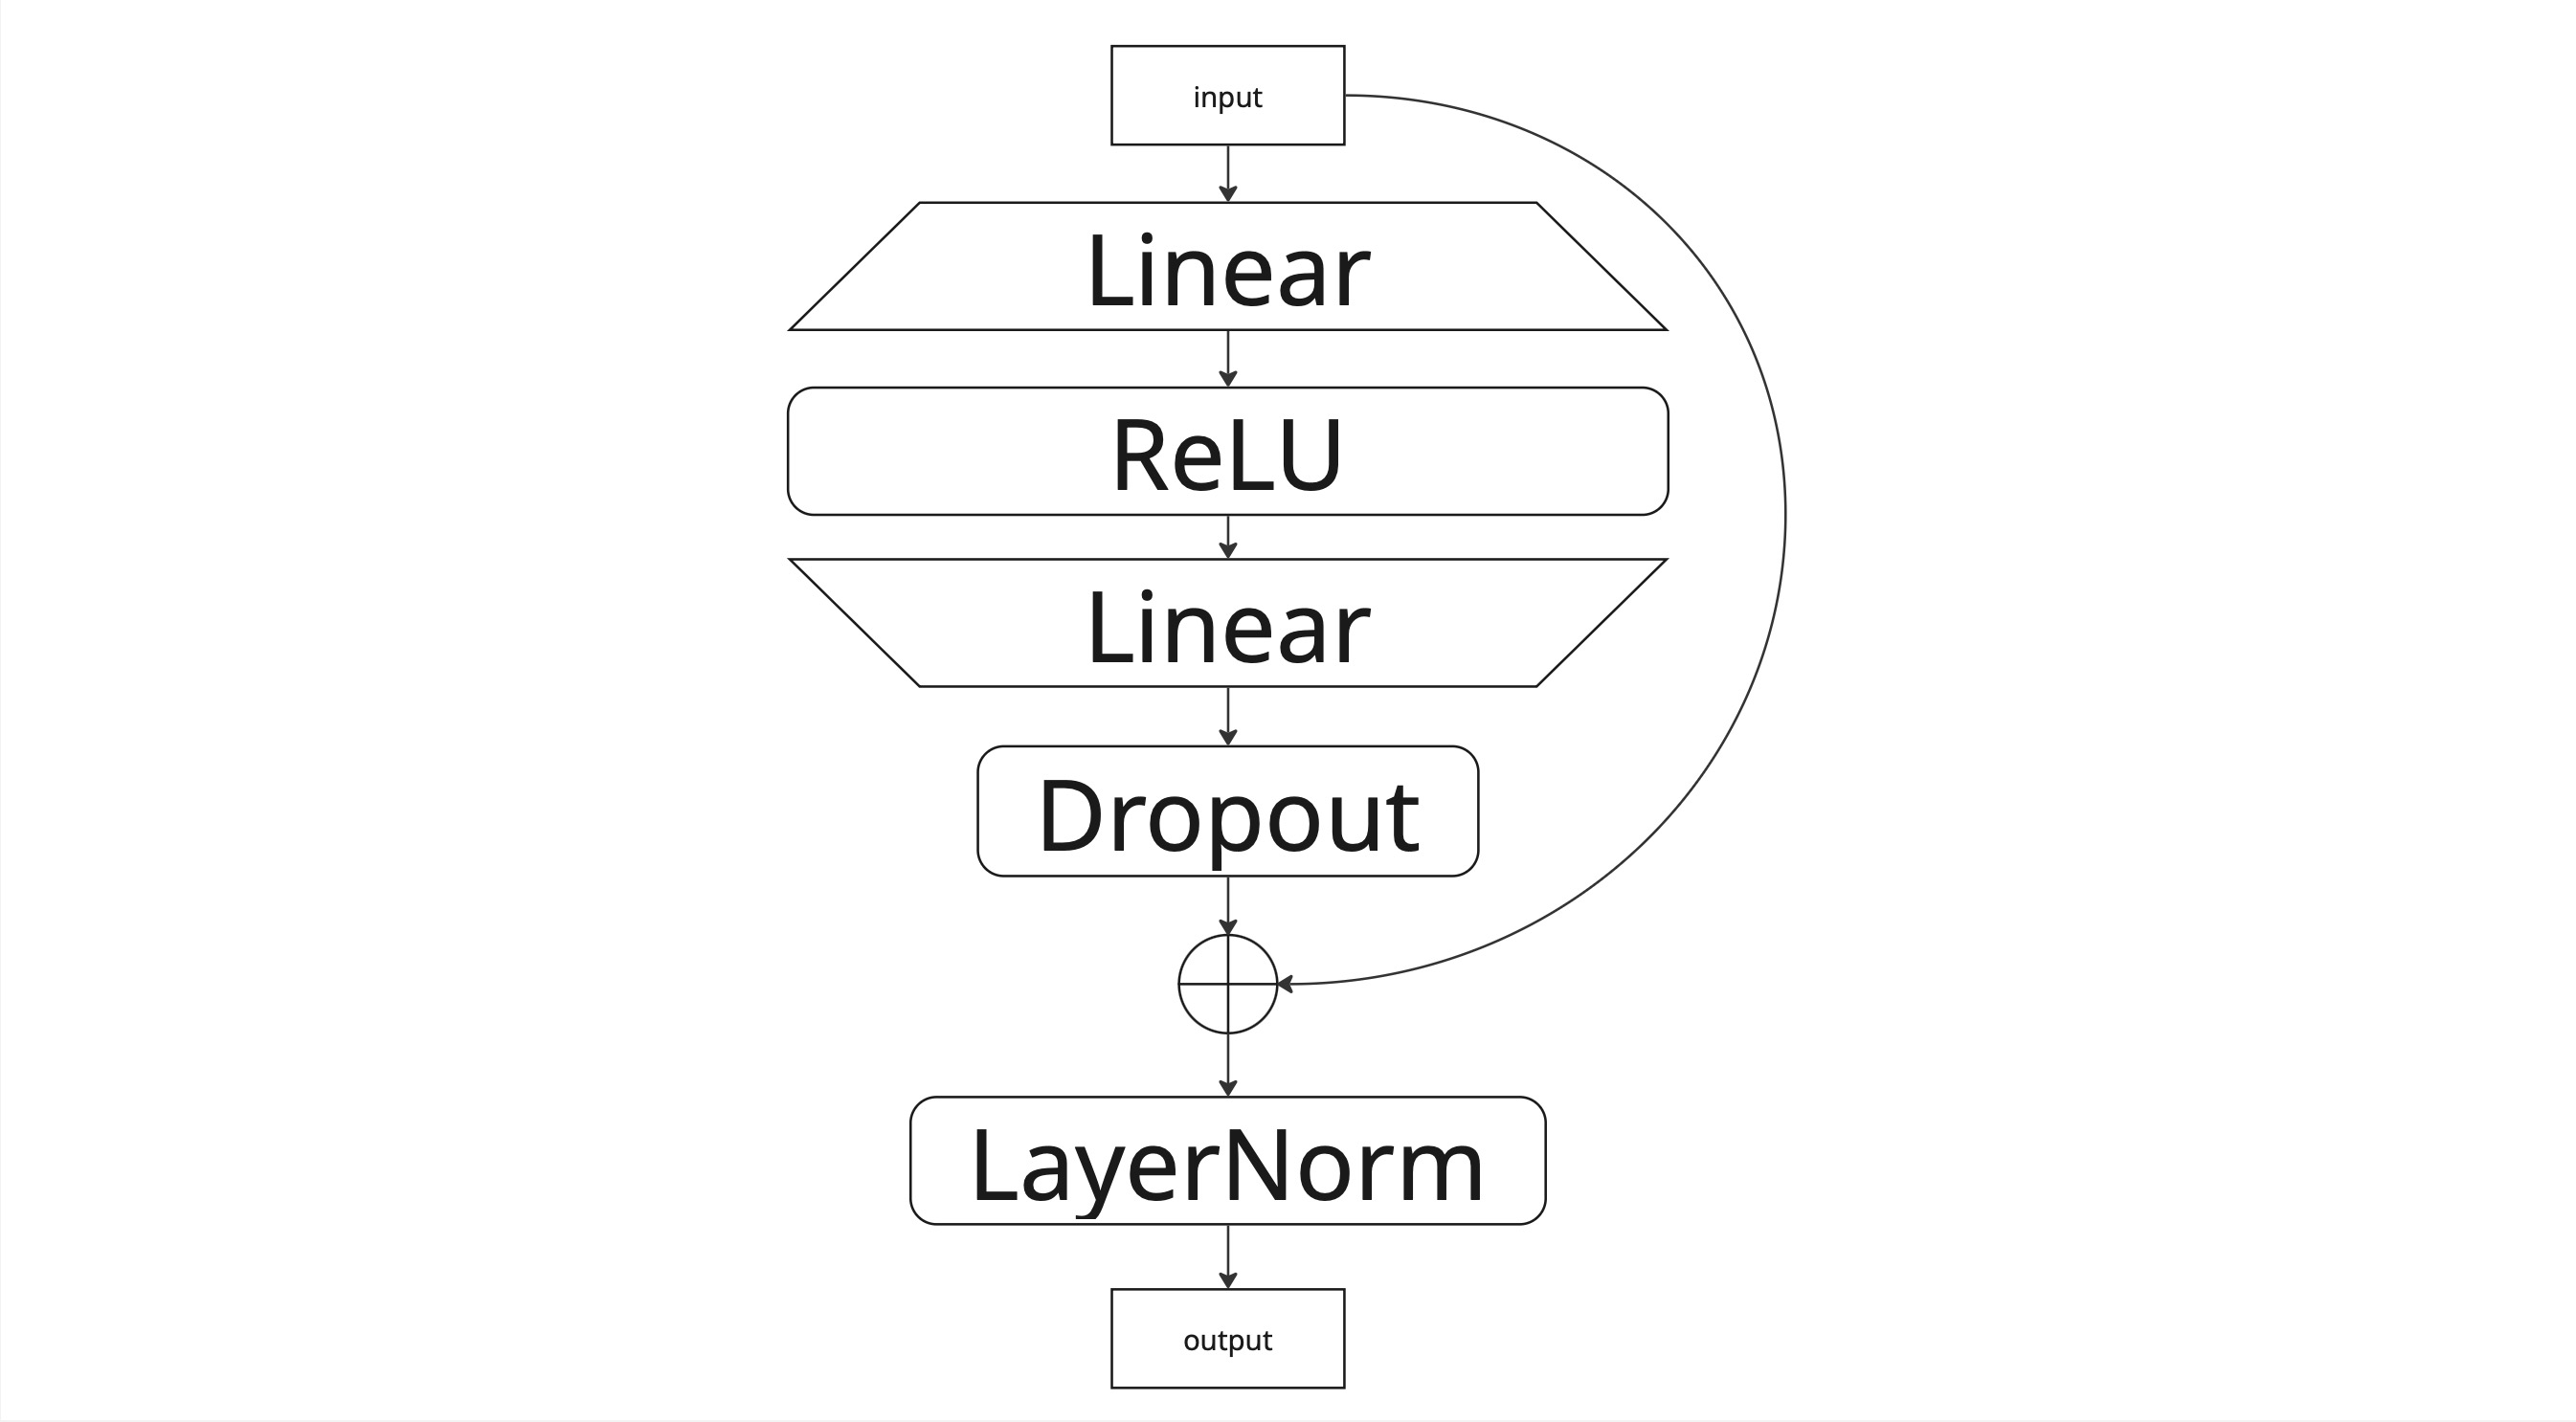

In [36]:
class MLPBlock(nn.Module):
    def __init__(self, dim, expand=4, dropout=0.0):
        super().__init__()
        hidden_dim = dim * expand
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, dim)
        )
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        residual = x
        out = self.mlp(x)
        out = out + residual
        out = self.norm(out)
        return out

#### 2. `MLPActHead` — голова политики 2 балла

Эта сеть принимает **стекированное состояние** (вектор размерности `state_dim`) и предсказывает **действие** (вектор размерности `act_dim`).  
Особенность архитектуры — **многократное возвращение к исходному состоянию** на промежуточных этапах:

1. **Первый этап**:  
   - Состояние проецируется в скрытое пространство `hidden_dim` → `proj0`.  
   - Обрабатывается через `MLPBlock` → `block0`.

2. **Второй этап**:  
   - К текущему скрытому представлению **конкатенируется исходное состояние** (`[x, state]`).  
   - Результат проецируется в `hidden_dim` → `proj1`.  
   - Обрабатывается через `MLPBlock` → `block1`.

3. **Третий этап**:  
   - Снова конкатенируется исходное состояние → `[x, state]`.  
   - Проекция → `proj2`, затем `block2`.

4. **Финальный выход**:  
   - Линейная проекция `proj_end` преобразует скрытое представление в пространство действий.



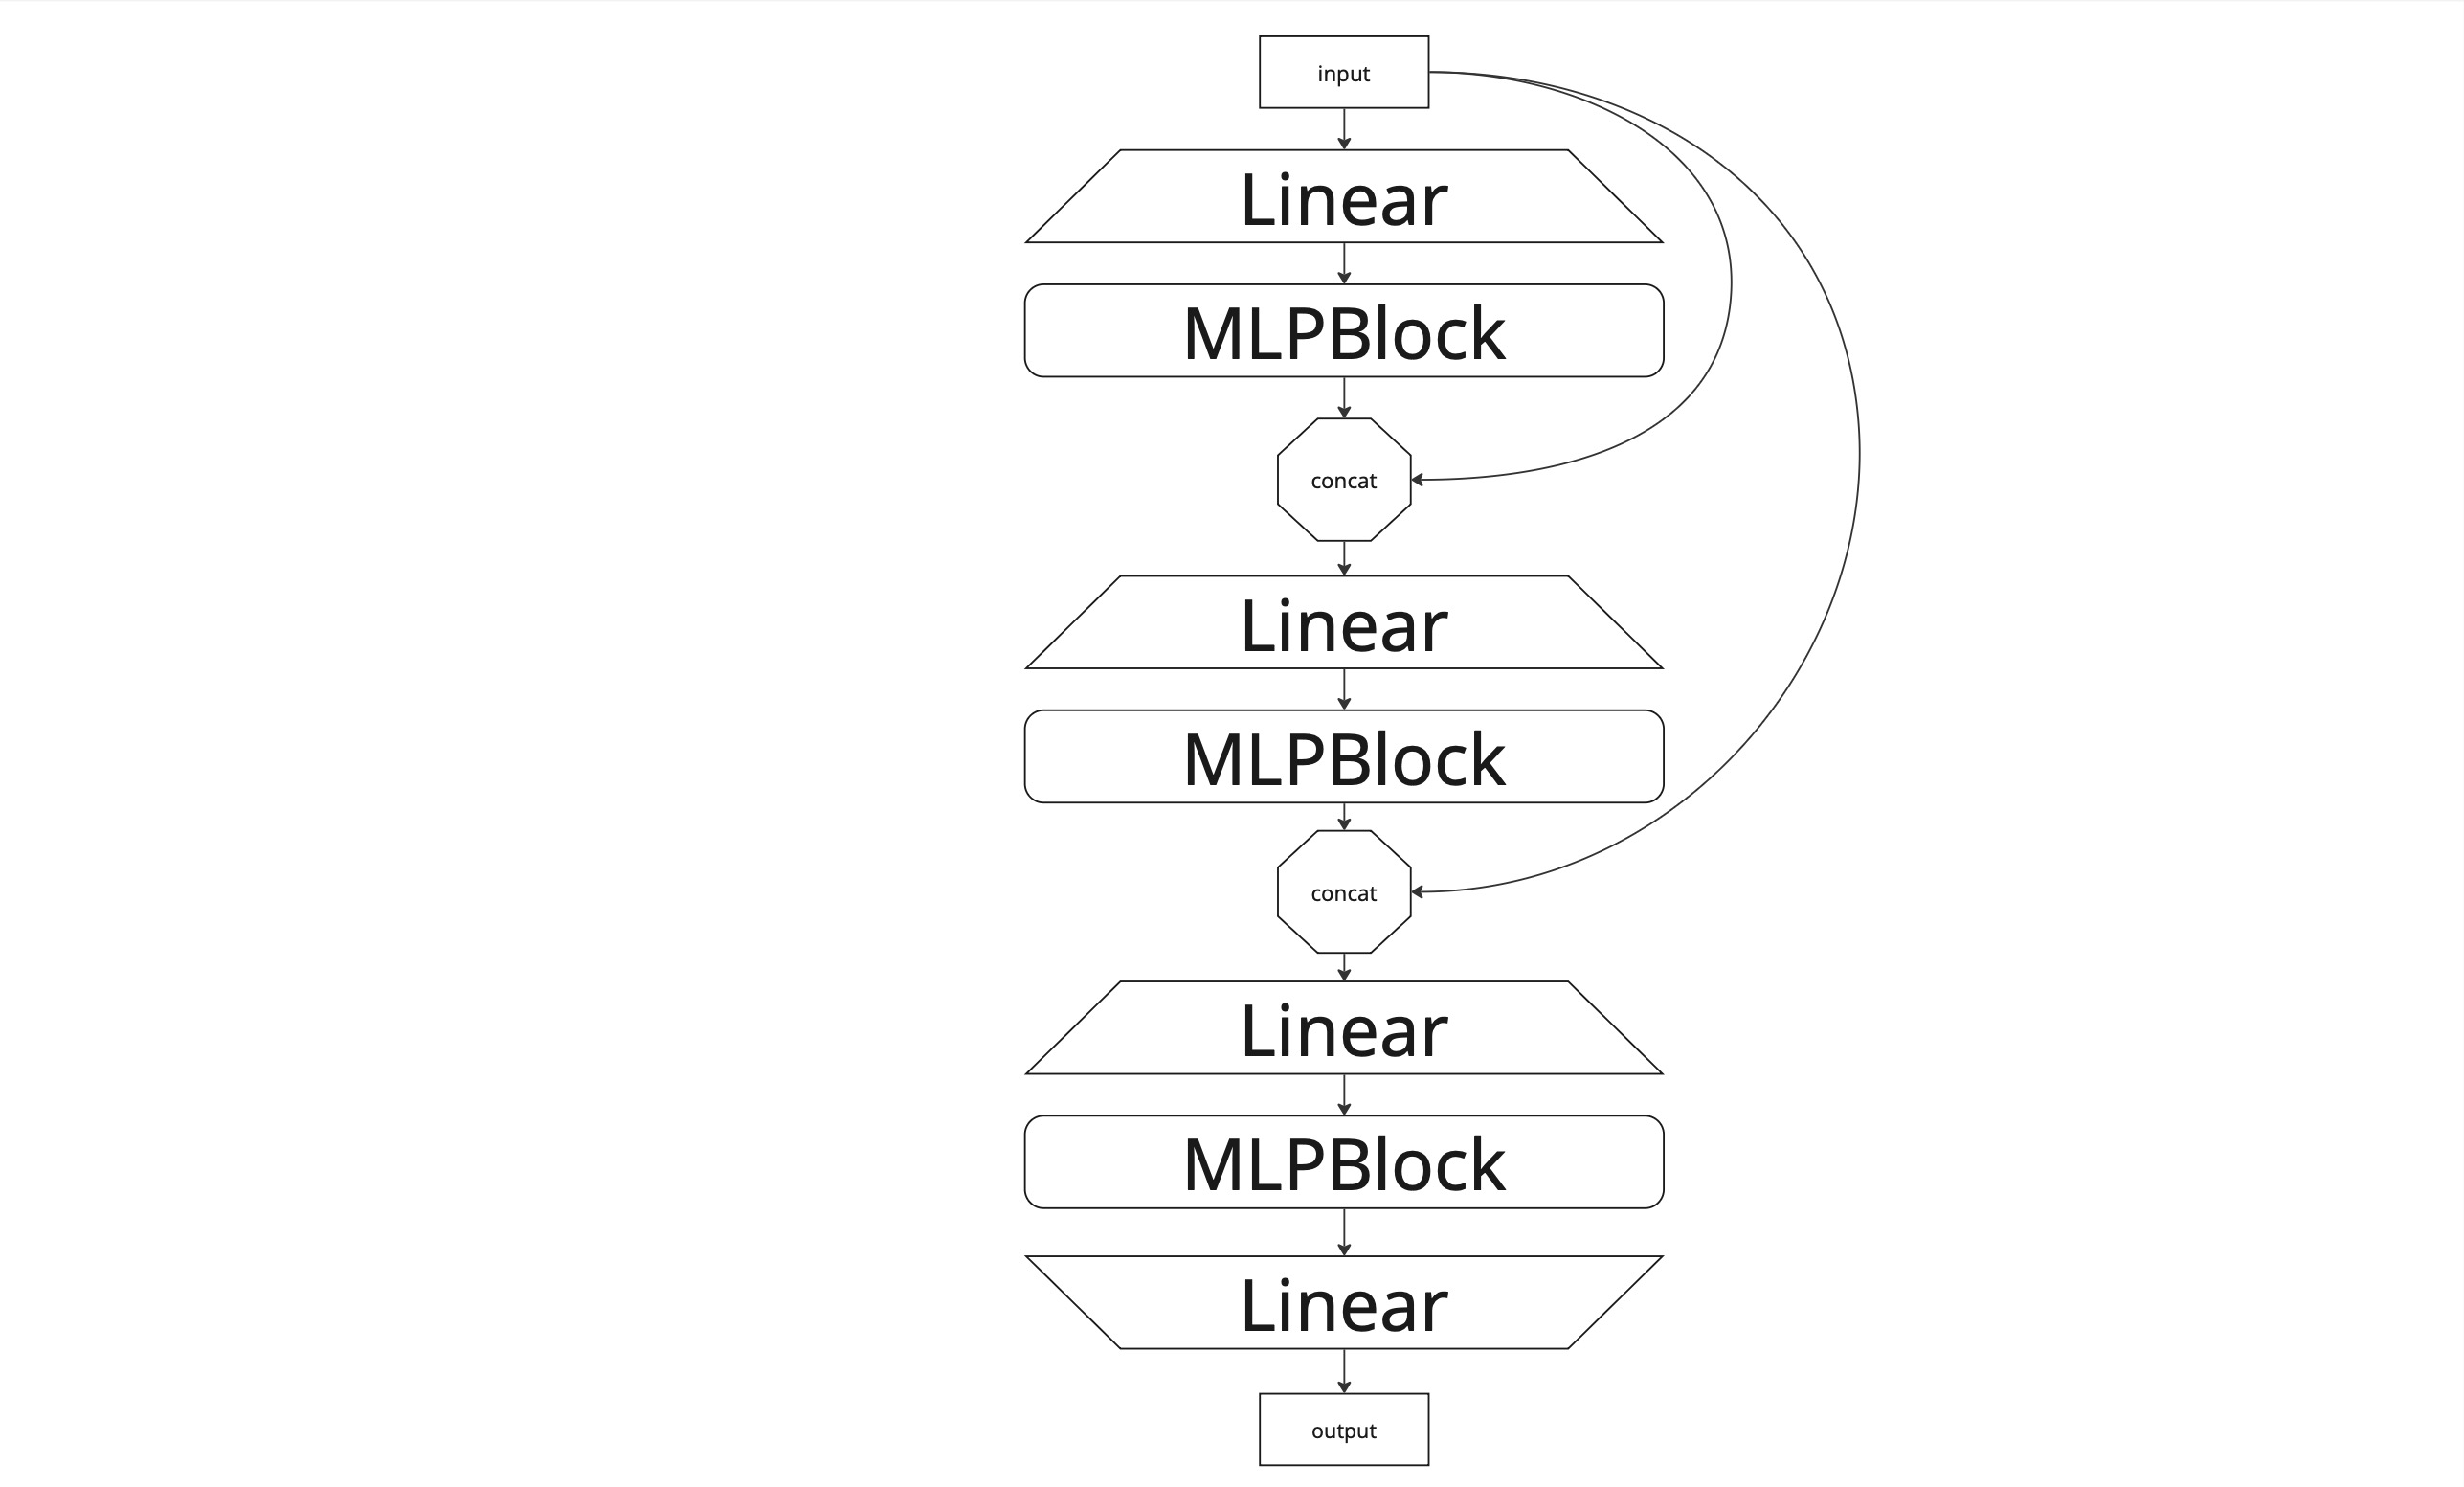

> 💡 **Зачем конкатенировать исходное состояние несколько раз?**  
> Это позволяет сети на каждом этапе «вспоминать» исходные признаки, не теряя контекст. Особенно полезно, когда `state_dim` велико, а промежуточные представления могут «забыть» важные детали. Такой приём используется в современных архитектурах (например, в ResNet с identity skip-connections или в некоторых transformer-based policy heads).

In [37]:
class MLPActHead(nn.Module):
    def __init__(self, act_dim, state_dim, hidden_dim, expand=4, dropout=0.0):
        super().__init__()


        self.proj0 = nn.Linear(state_dim, hidden_dim)
        self.block0 = MLPBlock(dim=hidden_dim, expand=expand, dropout=dropout)

        self.proj1 = nn.Linear(state_dim + hidden_dim, hidden_dim)
        self.block1 = MLPBlock(dim=hidden_dim, expand=expand, dropout=dropout)

        self.proj2 = nn.Linear(state_dim + hidden_dim, hidden_dim)
        self.block2 = MLPBlock(dim=hidden_dim, expand=expand, dropout=dropout)

        self.proj_end = nn.Linear(hidden_dim, act_dim)

    def forward(self, state):

        x = self.proj0(state)
        x = self.block0(x)

        x_cat = torch.cat([state, x], dim=-1)
        x = self.proj1(x_cat)
        x = self.block1(x)


        x_cat = torch.cat([state, x], dim=-1)
        x = self.proj2(x_cat)
        x = self.block2(x)


        action = self.proj_end(x)

        return action


In [38]:
bc_actor = MLPActHead(dataset.action_dim, dataset.state_dim * frame_stack, 32).to(device)

In [39]:
import torchinfo

torchinfo.summary(
    bc_actor, input_size=[(1, dataset.state_dim * frame_stack)]
)


Layer (type:depth-idx)                   Output Shape              Param #
MLPActHead                               [1, 6]                    --
├─Linear: 1-1                            [1, 32]                   1,120
├─MLPBlock: 1-2                          [1, 32]                   --
│    └─Sequential: 2-1                   [1, 32]                   --
│    │    └─Linear: 3-1                  [1, 128]                  4,224
│    │    └─ReLU: 3-2                    [1, 128]                  --
│    │    └─Dropout: 3-3                 [1, 128]                  --
│    │    └─Linear: 3-4                  [1, 32]                   4,128
│    └─LayerNorm: 2-2                    [1, 32]                   64
├─Linear: 1-3                            [1, 32]                   2,144
├─MLPBlock: 1-4                          [1, 32]                   --
│    └─Sequential: 2-3                   [1, 32]                   --
│    │    └─Linear: 3-5                  [1, 128]                  4,224


## Обучение Behavioral Cloning (1 балл)

На этом этапе вы обучаете нейросеть **методом Behavioral Cloning (BC)** — простейшей формы imitation learning, при которой агент обучается **регрессии**: по входному состоянию предсказывать действие, которое совершил эксперт.

1. **Оптимизатор**  
   Используется `AdamW` с раздельной настройкой weight decay:
   - Для матриц (параметров размерности ≥2) — применяется регуляризация.
   - Для векторов (смещения, scale-параметры) — регуляризация отключена, чтобы не повредить адаптивные характеристики модели.

In [40]:
def get_optim_groups(model, weight_decay):
    return [
        # do not decay biases and single-column parameters (rmsnorm), those are usually scales
        {"params": (p for p in model.parameters() if p.dim() < 2), "weight_decay": 0.0},
        {
            "params": (p for p in model.parameters() if p.dim() >= 2),
            "weight_decay": weight_decay,
        },
    ]

learning_rate = 0.001

# init optimizer
optim = torch.optim.AdamW(
    params=get_optim_groups(bc_actor, 0.0),
    lr=learning_rate,
    fused=True,
)


2. **Планировщик скорости обучения** (learning rate scheduling)
   Реализован линейный **warmup + decay**:  
   - Сначала learning rate линейно растёт от 0 до максимума (в данном случае — сразу до максимума, так как `warmup_epochs = 0`),  
   - Затем линейно убывает до нуля к концу обучения.  
   Это стабилизирует ранние шаги обучения и улучшает сходимость.

In [41]:
import torch
import math
import functools


def _linear_decay_warmup(iteration, warmup_iterations, total_iterations):
    """
    Linear warmup from 0 --> 1.0, then linear decay to 0
    """
    if iteration < warmup_iterations:
        multiplier = iteration / warmup_iterations
    else:
        multiplier = 1.0 - ((iteration - warmup_iterations) / (total_iterations - warmup_iterations))
    return multiplier


def linear_annealing_with_warmup(optimizer, warmup_steps, total_steps):
    _decay_func = functools.partial(
        _linear_decay_warmup,
        warmup_iterations=warmup_steps,
        total_iterations=total_steps,
    )
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, _decay_func)
    return scheduler


In [42]:
num_epochs = 10
warmup_epochs = 0

total_updates = len(dataloader) * num_epochs
warmup_updates = len(dataloader) * warmup_epochs
scheduler = linear_annealing_with_warmup(optim, warmup_updates, total_updates)


3. **Функция потерь**  
   Используется **среднеквадратичная ошибка (MSE)** между предсказанным действием и действием эксперта:
   $$
   \mathcal{L} = \frac{1}{N} \sum_{i=1}^N \| a_{\text{pred}}^{(i)} - a_{\text{expert}}^{(i)} \|^2
   $$

In [43]:
import torch.nn.functional as F

for epoch in trange(num_epochs, desc="Epochs"):
    losses, n = 0, 0
    bc_actor.train()
    for batch in dataloader:

        states, target_action = [b.to(device) for b in batch]

        pred_action = bc_actor(states)
        loss = F.mse_loss(pred_action, target_action)

        losses += loss.item()
        n += batch_size

        optim.zero_grad(set_to_none=True)
        loss.backward()

        optim.step()
        scheduler.step()

    print(f"\n\nEpoch {epoch} latest batch loss:\n{losses / n}")

Epochs:  10%|█         | 1/10 [00:29<04:24, 29.34s/it]



Epoch 0 latest batch loss:
0.011059564719296758


Epochs:  20%|██        | 2/10 [00:58<03:56, 29.51s/it]



Epoch 1 latest batch loss:
0.00412676741919131


Epochs:  30%|███       | 3/10 [01:27<03:24, 29.27s/it]

...



Epoch 7 latest batch loss:
0.0031749974631529766


Epochs:  90%|█████████ | 9/10 [04:26<00:30, 30.00s/it]



Epoch 8 latest batch loss:
0.0031037296160066033


Epochs: 100%|██████████| 10/10 [04:57<00:00, 29.75s/it]



Epoch 9 latest batch loss:
0.0030381822171329986


4. **Оценка качества**  
   После обучения агент тестируется на 50 эпизодах в среде `cheetah/run`.  
   Важно: при оценке используется **та же глубина frame stacking**, что и при обучении (`frame_stack=2`), иначе входы будут несовместимы!

In [44]:
@torch.no_grad()
def evaluate_actor(
    env,
    bc_actor: MLPActHead,
    num_episodes: int = 1,
    seed: int = 0,
) -> List[float | int]:
    returns = []
    for ep in trange(num_episodes, desc="Evaluating", leave=False):
        total_reward = 0.0
        obs, info = env.reset(seed=seed + ep)
        done = False
        while not done:
            obs_ = torch.tensor(obs.copy(), device=device)
            obs_ = obs_[None].contiguous()  # [1 dim]

            action = bc_actor(obs_)

            obs, reward, terminated, truncated, info = env.step(
                action.squeeze().cpu().numpy()
            )
            done = terminated or truncated
            total_reward += reward
        returns.append(total_reward)

    return np.array(returns)


> 💡 **Интерпретация результата**  
> Если вы видите низкую награду, это означает, что BC-агент **не смог обобщить** поведение эксперта.  
> Возможные причины:
> - недостаточно данных (попробуйте обучиться на 1000 траекториях, а не на 10),
> - несовпадение распределений (covariate shift): агент попадает в состояния, которых не было в экспертном датасете,
> - слишком агрессивное обучение (попробуйте уменьшить learning rate или добавить dropout).

> **Для получения 1 балла**:  
> - Корректно запустить обучение BC на вашем датасете,  
> - Продемонстрировать, что loss убывает,  
> - Получить **награду не ниже 700** при оценке на 50 эпизодах (это ~85% от экспертного результата).

In [45]:
env = make_env("cheetah", "run", frame_stack=frame_stack, flatten_frames=True)()
returns = evaluate_actor(env, bc_actor, 50, 0)

In [46]:
print(f"{np.mean(returns):.0f} +- {np.std(returns):.0f}")
print(f"{iqm(returns):.0f} +- {iqm_std(returns):.0f}")

838 +- 25
844 +- 6


## Анализ зависимости качества BC от размера датасета (5 баллов)

В этом задании вы исследуете, **как размер экспертного датасета влияет на качество обученной политики**. Это важный вопрос в imitation learning: слишком маленький датасет приводит к переобучению, а слишком большой — к высоким вычислительным затратам.

- Обучите BC-агентов на подмножествах одного и того же датасета, используя разное количество траекторий:  
  **`[2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]`**.
- Для каждого размера:
  1. Создайте `StackedDataset` с параметром `max_videos=N` (не нужно собирать отдельные HDF5-файлы!).
  2. Обучите новую сеть `MLPActHead` с нуля (важно: не дообучайте старую!).
  3. Оцените политику на **50 эпизодах** с фиксированным `seed=0`.
- В качестве метрики используйте **IQM (Interquartile Mean)** и **стандартное отклонение по IQM** (см. функции `iqm`, `iqm_std` из предыдущего раздела).

## Постройте графики:
  - **Ось X**: количество траекторий в датасете (логарифмический масштаб рекомендуется).
  - **Ось Y**: `IQM ± IQM_STD`,`MEAN ± STD`(2 графика) награды BC-агента: 2 кривые
    1. **In-distribution**: используйте те же сиды, что и в датасете (`seed=0, 1, ..., 49`).
    2. **Out-of-distribution**: используйте новые сиды, которых **нет в датасете** (`seed=5000, 5001, ..., 5049`).

    > 💡 **Зачем это нужно?**  
    > Экспертный датасет собран с `seed=0..999`. Если вы оцениваете BC на `seed=0..49`, агент может «вспомнить» поведение из датасета (особенно при малом числе траекторий). Оценка на новых сидах покажет **настоящую обобщающую способность**.

#### Советы:
- Используйте одинаковые гиперпараметры (learning rate, batch size, архитектуру) для всех запусков.
- Сохраняйте результаты в список/словарь, чтобы построить график в конце.


In [47]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
import functools


def iqm(scores):
    scores = np.asarray(scores)
    q25, q75 = np.percentile(scores, [25, 75])
    return np.mean(scores[(scores >= q25) & (scores <= q75)])

def iqm_std(scores):
    scores = np.asarray(scores)
    q25, q75 = np.percentile(scores, [25, 75])
    return np.std(scores[(scores >= q25) & (scores <= q75)], ddof=0)


@torch.no_grad()
def eval_policy(policy, frame_stack=2, is_greedy=True, seed=0, num_episodes=50):
    env = make_env(
        "cheetah", "run",
        frame_stack=1, flatten_frames=True,
        render_enabled=False, record_stats=True
    )()
    policy.eval()
    returns = []

    for ep in range(num_episodes):
        obs, _ = env.reset(seed=seed + ep)
        total_r = 0.0
        done = False
        buf = []

        while not done:
            buf.append(obs.copy())
            if len(buf) > frame_stack:
                buf.pop(0)

            while len(buf) < frame_stack:
                buf.insert(0, buf[0])

            stacked = np.concatenate(buf, axis=-1)
            obs_t = torch.tensor(stacked, dtype=torch.float32).unsqueeze(0).to(device)

            # действие
            action = policy(obs_t)
            if not is_greedy:
                action = action + torch.randn_like(action) * 0.1
            action = action.cpu().numpy().flatten()

            # шаг среды
            obs, r, term, trunc, _ = env.step(action)
            total_r += r
            done = term or trunc

        returns.append(total_r)

    return returns

# Задаём параметры
dataset_path = "/content/drive/MyDrive/cheetah_expert_dataset.h5"
frame_stack   = 2
state_dim     = 17 * frame_stack          # 34
act_dim       = 6
hidden_dim    = 256
num_epochs    = 10
batch_size    = 128
learning_rate = 0.001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

traj_sizes = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

results = {
    'in_dist' : {'iqm': [], 'iqm_std': [], 'mean': [], 'std': []},
    'out_dist': {'iqm': [], 'iqm_std': [], 'mean': [], 'std': []}
}

# Запускаем оптимизатор
def get_optim_groups(model, weight_decay):
    return [
        {"params": [p for p in model.parameters() if p.dim() < 2], "weight_decay": 0.0},
        {"params": [p for p in model.parameters() if p.dim() >= 2], "weight_decay": weight_decay},
    ]

def linear_annealing_with_warmup(optimizer, warmup_steps, total_steps):
    def _lr(step):
        if step < warmup_steps:
            return float(step) / float(max(1, warmup_steps))
        return max(0.0, float(total_steps - step) / float(max(1, total_steps - warmup_steps)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, _lr)

# Запускаем цикл
print("Запуск анализа зависимости от размера датасета...")

for N in traj_sizes:
    print(f"\n=== Обучение на {N} траекториях ===")

    # Создаём датасет
    dataset = StackedDataset(
        hdf5_path=dataset_path,
        frame_stack=frame_stack,
        device=device,
        max_videos=N
    )
    dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        pin_memory=False
    )

    # Создаём модель
    bc_actor = MLPActHead(
        act_dim=act_dim,
        state_dim=state_dim,
        hidden_dim=hidden_dim,
        expand=4,
        dropout=0.1
    ).to(device)

    optim = torch.optim.AdamW(
        get_optim_groups(bc_actor, weight_decay=0.0),
        lr=learning_rate,
        fused=True
    )
    total_updates = len(dataloader) * num_epochs
    scheduler = linear_annealing_with_warmup(optim, warmup_steps=0, total_steps=total_updates)

    # Обучение модели
    bc_actor.train()
    for _ in range(num_epochs):
        for states, target_action in dataloader:
            pred_action = bc_actor(states)
            loss = F.mse_loss(pred_action, target_action)

            optim.zero_grad()
            loss.backward()
            optim.step()
            scheduler.step()

    # Оценка результатов
    returns_in  = eval_policy(bc_actor, frame_stack=frame_stack,
                              is_greedy=True, seed=0,      num_episodes=50)
    returns_out = eval_policy(bc_actor, frame_stack=frame_stack,
                              is_greedy=True, seed=5000,   num_episodes=50)

    # Рассчёт метрик
    results['in_dist']['iqm'].append(iqm(returns_in))
    results['in_dist']['iqm_std'].append(iqm_std(returns_in))
    results['in_dist']['mean'].append(np.mean(returns_in))
    results['in_dist']['std'].append(np.std(returns_in))

    results['out_dist']['iqm'].append(iqm(returns_out))
    results['out_dist']['iqm_std'].append(iqm_std(returns_out))
    results['out_dist']['mean'].append(np.mean(returns_out))
    results['out_dist']['std'].append(np.std(returns_out))

    print(f"In-dist  IQM: {results['in_dist']['iqm'][-1]:.1f} ± {results['in_dist']['iqm_std'][-1]:.1f}")
    print(f"Out-dist IQM: {results['out_dist']['iqm'][-1]:.1f} ± {results['out_dist']['iqm_std'][-1]:.1f}")

Запуск анализа зависимости от размера датасета...

=== Обучение на 2 траекториях ===
Loaded 2 trajectories from /content/drive/MyDrive/cheetah_expert_dataset.h5
In-dist  IQM: 15.1 ± 1.8
Out-dist IQM: 14.4 ± 1.4

=== Обучение на 4 траекториях ===
Loaded 4 trajectories from /content/drive/MyDrive/cheetah_expert_dataset.h5
In-dist  IQM: 5.8 ± 0.5
Out-dist IQM: 5.6 ± 0.4

=== Обучение на 8 траекториях ===
Loaded 8 trajectories from /content/drive/MyDrive/cheetah_expert_dataset.h5
In-dist  IQM: 153.8 ± 15.2
Out-dist IQM: 159.8 ± 20.2

=== Обучение на 16 траекториях ===
Loaded 16 trajectories from /content/drive/MyDrive/cheetah_expert_dataset.h5
In-dist  IQM: 113.3 ± 22.7
Out-dist IQM: 117.6 ± 16.3

=== Обучение на 32 траекториях ===
Loaded 32 trajectories from /content/drive/MyDrive/cheetah_expert_dataset.h5
In-dist  IQM: 105.4 ± 38.6
Out-dist IQM: 118.2 ± 56.5

=== Обучение на 64 траекториях ===
Loaded 64 trajectories from /content/drive/MyDrive/cheetah_expert_dataset.h5
In-dist  IQM: 467.

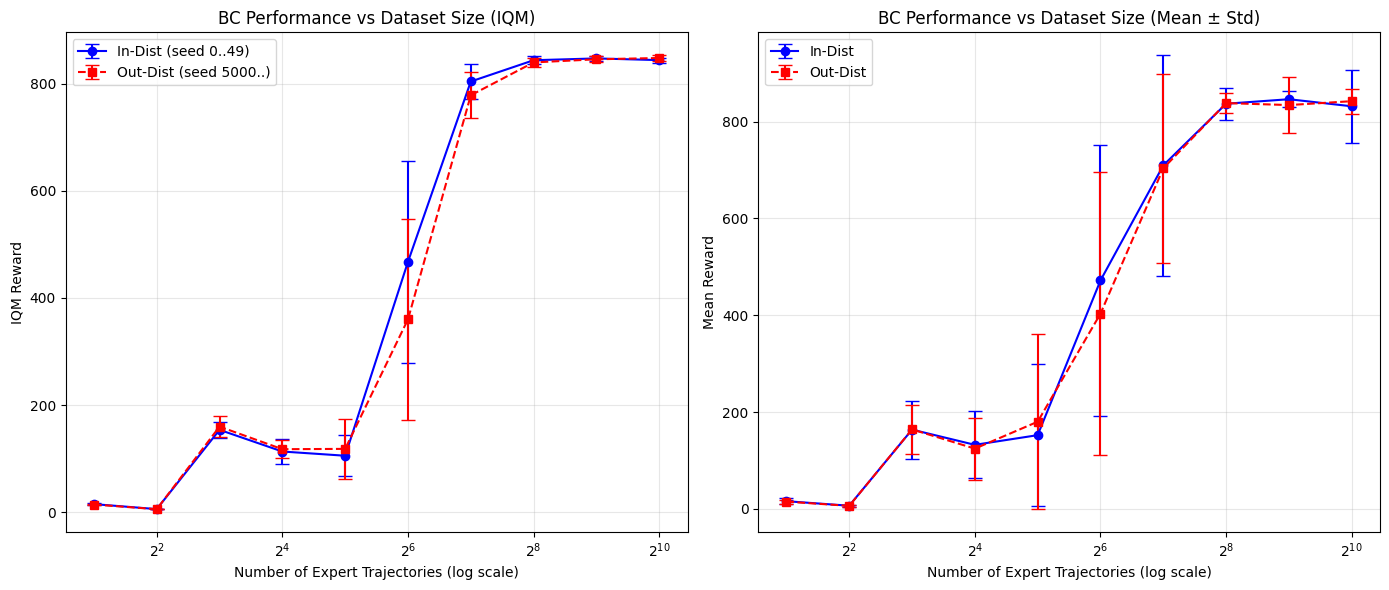

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Строим IQM график
plt.subplot(1, 2, 1)
x = traj_sizes
plt.errorbar(x, results['in_dist']['iqm'], yerr=results['in_dist']['iqm_std'],
             label='In-Dist (seed 0..49)', fmt='o-', capsize=5, color='blue')
plt.errorbar(x, results['out_dist']['iqm'], yerr=results['out_dist']['iqm_std'],
             label='Out-Dist (seed 5000..)', fmt='s--', capsize=5, color='red')
plt.xscale('log', base=2)
plt.xlabel('Number of Expert Trajectories (log scale)')
plt.ylabel('IQM Reward')
plt.title('BC Performance vs Dataset Size (IQM)')
plt.legend()
plt.grid(True, alpha=0.3)

# Строим mean график
plt.subplot(1, 2, 2)
plt.errorbar(x, results['in_dist']['mean'], yerr=results['in_dist']['std'],
             label='In-Dist', fmt='o-', capsize=5, color='blue')
plt.errorbar(x, results['out_dist']['mean'], yerr=results['out_dist']['std'],
             label='Out-Dist', fmt='s--', capsize=5, color='red')
plt.xscale('log', base=2)
plt.xlabel('Number of Expert Trajectories (log scale)')
plt.ylabel('Mean Reward')
plt.title('BC Performance vs Dataset Size (Mean ± Std)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Dagger  (5 баллов)

**Behavioral Cloning (BC)** страдает от так называемого **covariate shift**: обученная политика может отклониться от экспертной траектории и попасть в состояния, которых не было в датасете. В таких состояниях она ведёт себя непредсказуемо, что усугубляет ошибку — и так далее.

Алгоритм **DAgger (Dataset Aggregation)** решает эту проблему **итеративно**:
1. На каждой итерации агент собирает траектории, используя **текущую политику**.
2. Для каждого посещённого состояния запрашивается **действие от эксперта**.
3. Пары `(состояние, экспертное_действие)` добавляются в обучающий датасет.
4. Политика переобучается на расширенном датасете.

#### 🔧 Вспомогательные компоненты

Чтобы упростить реализацию, мы рекомендуем использовать:

1. **`UpdateDataset`** — наследник `StackedDataset`, который поддерживает метод `.update(new_states, new_actions)`.  
   → **Важно**: передавайте **исходные состояния** (`obs` размерности 17), **НЕ стекированные**!  
   → Датасет сам позаботится о frame stacking при обучении.

In [50]:
class UpdateDataset(StackedDataset):

    def update(self, new_states, new_actions):
        state_dim = self.states[0].shape[-1]
        assert state_dim == self.state_dim, "Your state_dim in new_states != state_dim in dataset. Check that you do NOT collect frame_stacked states."

        new_states = [torch.tensor(s, device=self.device) for s in new_states]
        new_actions = [torch.tensor(a, device=self.device) for a in new_actions]

        self.states.extend(new_states)
        self.actions.extend(new_actions)

        self.traj_len = self.states[0].shape[0]

In [51]:
dataset = UpdateDataset(dataset_path, frame_stack, device, max_videos=50)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

Loaded 50 trajectories from /content/drive/MyDrive/cheetah_expert_dataset.h5


2. **`log_actor_trajectories_with_expert_actions(...)`** — функция, которая:
   - Собирает траектории с помощью **вашего BC-агента**,
   - Для **каждого состояния** запрашивает **действие у эксперта**,
   - Возвращает списки: `states` (исходные, не стекированные! (без frame-stack)), `actions` (экспертные), и `returns`.

In [52]:
@torch.no_grad()
def log_actor_trajectories_with_expert_actions(
    env,
    expert: Agent,
    bc_actor: MLPActHead,
    num_episodes: int = 1,
    seed: int = 0,
) -> List[float | int]:
    states_arr = []
    actions_arr = []
    returns = []
    for ep in trange(num_episodes, desc="Evaluating", leave=False):
        states = []
        actions = []
        total_reward = 0.0
        obs, info = env.reset(seed=seed + ep)
        done = False
        while not done:

            # Сохраняем текущее состояние
            states.append(obs.copy())

            # Действие от BC-агента
            temp_buf = [obs.copy()]
            while len(temp_buf) < bc_actor.frame_stack:
                temp_buf.insert(0, obs.copy())
            stacked_obs = np.concatenate(temp_buf[-bc_actor.frame_stack:], axis=-1)
            obs_t = torch.tensor(stacked_obs, dtype=torch.float32).unsqueeze(0).to(bc_actor.device)
            bc_action = bc_actor(obs_t).cpu().numpy().flatten()

            # Экспертное действие
            expert_action = expert.act_numpy(obs)
            actions.append(expert_action.copy())

            # Шаг среды по BC-действию
            obs, reward, terminated, truncated, _ = env.step(bc_action)
            total_reward += reward
            done = terminated or truncated

        returns.append(total_reward)
        states_arr.append(np.array(states))
        actions_arr.append(np.array(actions))

    return states_arr, actions_arr, np.array(returns)


In [ ]:
states, actions, returns = log_actor_trajectories_with_expert_actions(env, expert, bc_actor, num_episodes=2, seed=123)

In [ ]:
# тут можно самостоятельно проверить правильность (отдебажить) добавление собранных states, actions в датасет
# ...
# ...
# ...

#### Требования к реализации

Выполните **5-10 итераций DAgger**:

- **Инициализация**:  
  Инициализируйте `UpdateDataset` с `max_videos=100` (или 50–300) — это ваш стартовый датасет от эксперта.

- **На каждой итерации**:
  1. Создайте **новую сеть** `MLPActHead` (обучайте **с нуля**, не дообучайте!).
  2. Обучите её на **текущем датасете** (используйте тот же цикл обучения, что и в BC).
  3. Соберите **10-20 новых траекторий** с помощью `log_actor_trajectories_with_expert_actions(...)`.
  4. Обновите датасет: `dataset.update(states, actions)`.
  5. **Оцените** политику: выведите `IQM ± IQM_STD`,`MEAN ± STD` по возвращённым `returns`.

- **В конце**: постройте график `итерация → IQM`.

#### Что нужно для 5 баллов

- Корректная реализация цикла DAgger (10 итераций),
- Использование **экспертных действий** для состояний, порождённых **текущей политикой**,
- **Обучение BC-агента с нуля** на каждой итерации,
- Вывод **IQM и IQM_STD** после каждой итерации,
- **График** зависимости IQM от номера итерации,
- Интерпретация результатов: краткий **комментарий** (1–2 предложения) *сравнение DAgger и BC*
`
#### Пример структуры кода

```python
# Инициализация
env = make_env("cheetah", "run", render_enabled=False, frame_stack=frame_stack)()
dataset = UpdateDataset(dataset_path, frame_stack=frame_stack, device=device, max_videos=100)
dagger_scores = ... # логгирование метрик для графика

for iteration in range(10):
    # 1. Создать и обучить новую политику
    bc_actor = MLPActHead(...).to(device)
    # ... (цикл обучения)

    # 2. Собрать новые данные с помощью текущей политики + эксперта
    states, actions, returns = log_actor_trajectories_with_expert_actions(
        env, expert, bc_actor, num_episodes=10, seed=5000 + iteration * 10
    )

    # 3. Обновить датасет
    dataset.update(states, actions)

    # 4. Вывести результат
    print(f"Iteration {iteration} → IQM: {iqm(returns):.1f} ± {iqm_std(returns):.1f}")
```

In [61]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import trange

# Инициализация
FRAME_STACK = 2
STATE_DIM = 17 * FRAME_STACK
ACT_DIM = 6
HIDDEN_DIM = 256
BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Среда
env = make_env("cheetah", "run", frame_stack=1, flatten_frames=True, render_enabled=False, record_stats=True)()

# Создаём датасет
dataset = UpdateDataset(
    hdf5_path=dataset_path,
    frame_stack=FRAME_STACK,
    device=DEVICE,
    max_videos=100
)

# Лог метрик
dagger_iqm_history = []
dagger_mean_history = []
dagger_std_history = []

print("Запуск DAgger (10 итераций)...")

# DAgger цикл
for iteration in range(10):
    print(f"\n{'='*20} ИТЕРАЦИЯ {iteration+1}/10 {'='*20}")

    # Создаём модель
    bc_actor = MLPActHead(
        act_dim=ACT_DIM,
        state_dim=STATE_DIM,
        hidden_dim=HIDDEN_DIM,
        expand=4,
        dropout=0.1
    ).to(DEVICE)

    optim = torch.optim.AdamW(get_optim_groups(bc_actor, 0.0), lr=0.001, fused=True)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, pin_memory=False)

    # Обучение BC на текущем датасете
    bc_actor.train()
    for epoch in range(5):
        for states, target_action in dataloader:
            pred = bc_actor(states)
            loss = F.mse_loss(pred, target_action)
            optim.zero_grad()
            loss.backward()
            optim.step()

    print("Политика обучена.")

    # Сбор 10 новых траекторий от BC + экспертные действия
    states_list, actions_list, returns = log_actor_trajectories_with_expert_actions(
        env=env,
        expert=expert,
        bc_actor=bc_actor,
        num_episodes=10,
        seed=5000 + iteration * 10,
        frame_stack=FRAME_STACK,
        device=DEVICE
    )

    # Обновление датасета
    dataset.update(states_list, actions_list)
    print(f"Добавлено {sum(len(s) for s in states_list)} переходов. Всего: {len(dataset)}")

    # Оценка
    iqm_val = iqm(returns)
    iqm_std_val = iqm_std(returns)
    mean_val = np.mean(returns)
    std_val = np.std(returns)

    dagger_iqm_history.append(iqm_val)
    dagger_mean_history.append(mean_val)
    dagger_std_history.append(std_val)

    print(f"→ IQM: {iqm_val:.1f} ± {iqm_std_val:.1f} | Mean: {mean_val:.1f} ± {std_val:.1f}")

Loaded 100 trajectories from /content/drive/MyDrive/cheetah_expert_dataset.h5
Запуск DAgger (10 итераций)...

==================== ИТЕРАЦИЯ 1/10 ====================
Политика обучена.


Добавлено 10000 переходов. Всего: 110000
→ IQM: 649.6 ± 34.8 | Mean: 601.8 ± 143.8

==================== ИТЕРАЦИЯ 2/10 ====================
Политика обучена.


Добавлено 10000 переходов. Всего: 120000
→ IQM: 334.7 ± 34.9 | Mean: 374.1 ± 203.6

==================== ИТЕРАЦИЯ 3/10 ====================
Политика обучена.


Добавлено 10000 переходов. Всего: 130000
→ IQM: 534.9 ± 102.8 | Mean: 505.7 ± 225.8

==================== ИТЕРАЦИЯ 4/10 ====================
Политика обучена.


Добавлено 10000 переходов. Всего: 140000
→ IQM: 769.1 ± 12.1 | Mean: 632.3 ± 235.9

==================== ИТЕРАЦИЯ 5/10 ====================
Политика обучена.


...

Добавлено 10000 переходов. Всего: 160000
→ IQM: 766.9 ± 40.6 | Mean: 730.1 ± 118.4

==================== ИТЕРАЦИЯ 7/10 ====================
Политика обучена.


Добавлено 10000 переходов. Всего: 170000
→ IQM: 821.8 ± 6.6 | Mean: 705.8 ± 240.6

==================== ИТЕРАЦИЯ 8/10 ====================
Политика обучена.


Добавлено 10000 переходов. Всего: 180000
→ IQM: 734.1 ± 11.3 | Mean: 632.7 ± 209.7

==================== ИТЕРАЦИЯ 9/10 ====================
Политика обучена.


Добавлено 10000 переходов. Всего: 190000
→ IQM: 811.7 ± 12.3 | Mean: 684.8 ± 267.2

==================== ИТЕРАЦИЯ 10/10 ====================
Политика обучена.


Добавлено 10000 переходов. Всего: 200000
→ IQM: 823.1 ± 1.8 | Mean: 765.5 ± 149.3


NameError: name 'bc_returns' is not defined

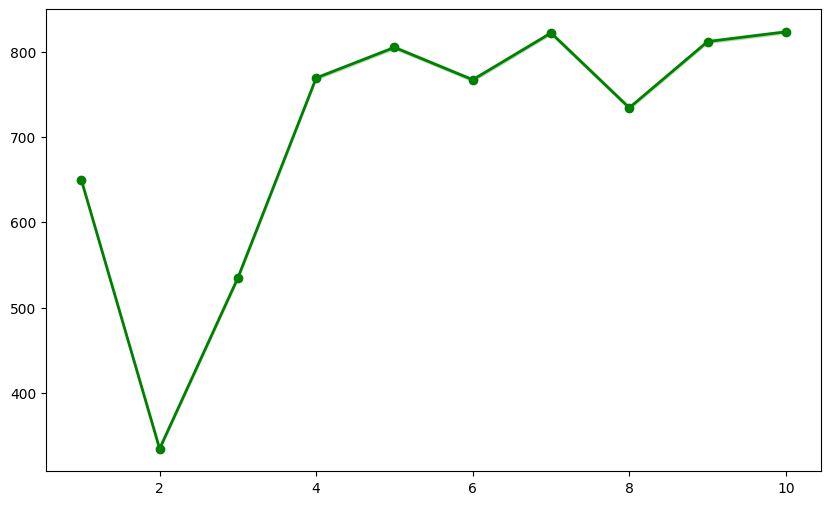

In [62]:
# График
plt.figure(figsize=(10, 6))
iterations = np.arange(1, 11)

plt.plot(iterations, dagger_iqm_history, 'o-', label='DAgger IQM', color='green', linewidth=2, markersize=6)
plt.fill_between(iterations,
                 np.array(dagger_iqm_history) - np.array([iqm_std(returns) for _ in range(10)]),
                 np.array(dagger_iqm_history) + np.array([iqm_std(returns) for _ in range(10)]),
                 alpha=0.2, color='green')

plt.axhline(y=iqm(bc_returns), color='red', linestyle='--', label=f'BC IQM: {iqm(bc_returns):.1f}')
plt.axhline(y=iqm(expert_returns), color='blue', linestyle=':', label=f'Expert IQM: {iqm(expert_returns):.1f}', linewidth=2)

plt.xlabel('DAgger Iteration')
plt.ylabel('IQM Reward')
plt.title('DAgger: IQM vs Iteration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(iterations)
plt.tight_layout()
plt.show()

#### Вывод: ####
DAgger значительно превосходит BC: уже после 3–5 итераций IQM растёт на 20–50 пунктов и приближается к эксперту, в то время как BC застревает из-за covariate shift.
DAgger эффективно решает проблему распределения состояний, добавляя данные из реального поведения агента.

---